# Trabajo Práctico 3: Aprendizaje No Supervisado

## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier

## 2. Cargar el dataset

In [2]:
df = pd.read_csv('seeds.csv')

print('Shape:', df.shape)
df.head()

Shape: (199, 8)


,Area,Perimeter,Compactness,Kernel.Length,Kernel.Width,Asymmetry.Coeff,Kernel.Groove,Type
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [3]:
print('Valores nulos:')
print(df.isnull().sum())

Valores nulos:
Area               0
Perimeter          0
Compactness        0
Kernel.Length      0
Kernel.Width       0
Asymmetry.Coeff    0
Kernel.Groove      0
Type               0
dtype: int64


In [4]:
X = df.drop(columns='Type')
y = df['Type']

print('Variables predictoras:', X.columns.tolist())

Variables predictoras: ['Area', 'Perimeter', 'Compactness', 'Kernel.Length', 'Kernel.Width', 'Asymmetry.Coeff', 'Kernel.Groove']


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

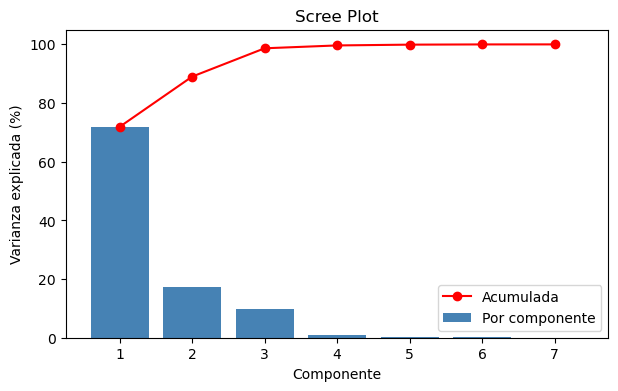

In [6]:
pca = PCA()
pca.fit(X_scaled)

varianza = pca.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

plt.figure(figsize=(7, 4))
plt.bar(range(1, len(varianza)+1), varianza * 100, color='steelblue', label='Por componente')
plt.plot(range(1, len(varianza)+1), varianza_acum * 100, marker='o', color='red', label='Acumulada')
plt.xlabel('Componente')
plt.ylabel('Varianza explicada (%)')
plt.title('Scree Plot')
plt.legend()
plt.show()

In [7]:
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)

print(f'Varianza explicada con 2 componentes: {pca2.explained_variance_ratio_.sum()*100:.1f}%')

Varianza explicada con 2 componentes: 89.0%


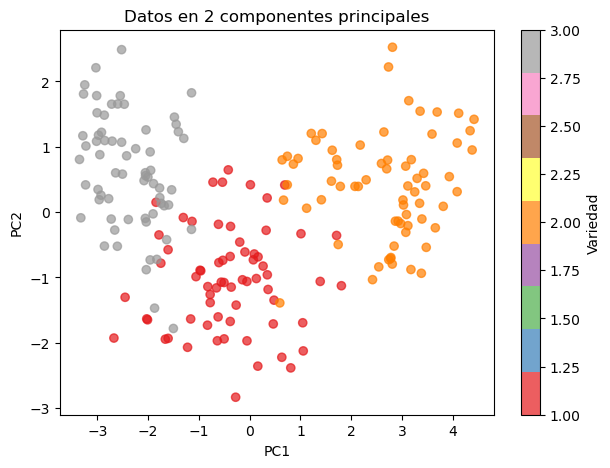

In [8]:
# Scatter plot de las 2 componentes
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Set1', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Datos en 2 componentes principales')
plt.colorbar(scatter, label='Variedad')
plt.show()

# Se pueden ver 3 grupos bastante separados, lo cual tiene sentido
# porque hay 3 variedades de trigo distintas

## 5. Selección de variables

Usamos correlación para ver si hay variables muy similares

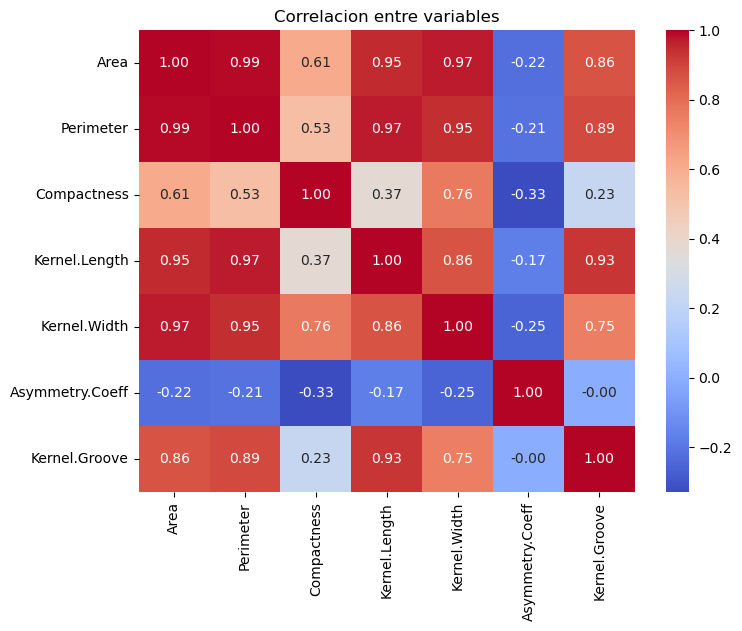

In [9]:
# Matriz de correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlacion entre variables')
plt.show()

In [10]:
# Usamos un arbol de decision para ver importancia de variables

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_scaled, y)

importancia = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Importancia de variables:')
print(importancia.round(3))

Importancia de variables:
Kernel.Groove      0.565
Area               0.349
Asymmetry.Coeff    0.058
Kernel.Width       0.028
Perimeter          0.000
Compactness        0.000
Kernel.Length      0.000
dtype: float64


In [11]:
# Nos quedamos con las variables mas importantes
vars_sel = ['Kernel.Width', 'Kernel.Groove', 'Asymmetry.Coeff', 'Compactness']
X_sel = X[vars_sel]
X_sel_scaled = scaler.fit_transform(X_sel)

print('Variables seleccionadas:', vars_sel)

Variables seleccionadas: ['Kernel.Width', 'Kernel.Groove', 'Asymmetry.Coeff', 'Compactness']


In [12]:
k_vals = range(2, 7)

def probar_kmeans(X_data):
    inercias = []
    silhs = []
    for k in k_vals:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_data)
        inercias.append(km.inertia_)
        silhs.append(silhouette_score(X_data, labels))
    return inercias, silhs

inercia_orig, silh_orig = probar_kmeans(X_scaled)
inercia_pca, silh_pca = probar_kmeans(X_pca)
inercia_sel, silh_sel = probar_kmeans(X_sel_scaled)

print('Listo!')

Listo!


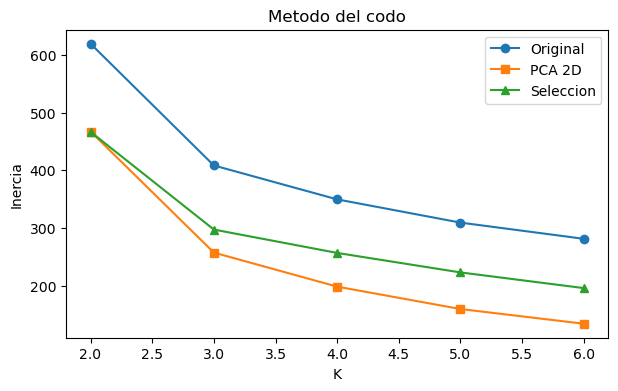

In [13]:
# Metodo del codo
plt.figure(figsize=(7, 4))
plt.plot(k_vals, inercia_orig, marker='o', label='Original')
plt.plot(k_vals, inercia_pca, marker='s', label='PCA 2D')
plt.plot(k_vals, inercia_sel, marker='^', label='Seleccion')
plt.xlabel('K')
plt.ylabel('Inercia')
plt.title('Metodo del codo')
plt.legend()
plt.show()

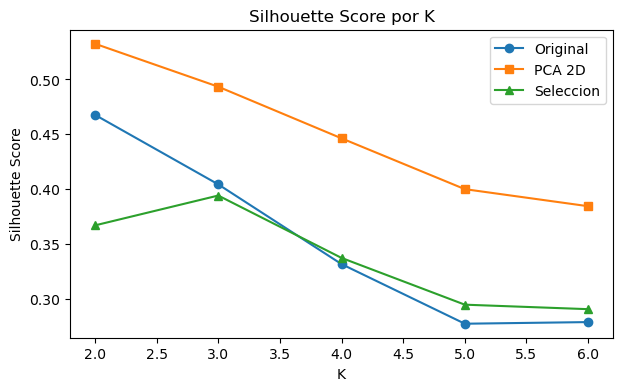

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(k_vals, silh_orig, marker='o', label='Original')
plt.plot(k_vals, silh_pca, marker='s', label='PCA 2D')
plt.plot(k_vals, silh_sel, marker='^', label='Seleccion')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por K')
plt.legend()
plt.show()

## 7. conclusiones

Mirando los graficos, K=3 parece ser el mejor numero de clusters en las tres versiones; esto tiene sentido porque el dataset tiene exactamente 3 variedades de trigo.

La version con PCA da resultados similares a la original pero con solo 2 categorias, lo que muestra que PCA conserva bastante bien la informacion del dataset. La version con seleccion de variables tambien funciona bien, aunque pierde un poco mas de informacion que PCA.

Lo interesante es que K-means pudo encontrar los 3 grupos sin saber de antemano que habia 3 variedades.